In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import astropy.units as u

%matplotlib inline

In [133]:
# load some helper functions
from ingest import ingest_data, alert_lc, plot_alert_lc, unpack_lc_features

# automagic jupyter for autorefreshing python script without restarting notebook
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
# path to your data
data_path = "/Users/atzanida/Downloads/rubindata"

### Stack all `.parquet` files into a single dataframe

In [4]:
data = ingest_data(data_path)

100%|██████████| 605/605 [00:19<00:00, 30.52it/s]


### Look at the first 3 rows

In [38]:
data.head(3)

,diaObject,prvDiaSources,prvDiaForcedSources,lc_features,xm,diaObjectId
0,"{'dec': 7.700485713444512, 'decErr': 1.9064212...","[{'apFlux': 3030.575439453125, 'apFluxErr': 88...","[{'band': 'i', 'dec': 7.700483330603901, 'dete...","{'g': {'amplitude': 2921.7946166992188, 'ander...",{'gaiadr3_DR3Name': 'Gaia DR3 3901147730152421...,170028526632697879
1,"{'dec': 7.97952700516745, 'decErr': 3.86851382...","[{'apFlux': 428.8632507324219, 'apFluxErr': 92...","[{'band': 'i', 'dec': 7.979522816252767, 'dete...","{'g': {'amplitude': 5502.379150390625, 'anders...",{'gaiadr3_DR3Name': 'Gaia DR3 3901915910822893...,170028526451294284
2,"{'dec': 3.3527564348717065, 'decErr': 2.847441...","[{'apFlux': 1049.7255859375, 'apFluxErr': 352....","[{'band': 'r', 'dec': 3.352740344746218, 'dete...","{'g': {'amplitude': 1882.7117614746094, 'ander...",{'gaiadr3_DR3Name': 'Gaia DR3 3848481977883394...,313871014343737493


### We can even look at the `xm` column that contains the Gaia DR3 crossmatch with sources with good parallax measurements

In [70]:
data.head(1)['xm'].loc[0]

{'gaiadr3_DR3Name': 'Gaia DR3 3901147730152421888',
 'gaiadr3_Plx': 2.9858999252319336,
 'gaiadr3_VarFlag': 0,
 'gaiadr3_e_Plx': 0.10909999907016754,
 'gcvs_type': None,
 'legacydr8_e_zphot': 0.9020000100135803,
 'legacydr8_fqual': 0,
 'legacydr8_pstar': 1.0,
 'legacydr8_zphot': 1.1430000066757202,
 'mangrove_2MASS_name': None,
 'mangrove_HyperLEDA_name': None,
 'mangrove_ang_dist': None,
 'mangrove_lum_dist': None,
 'simbad_otype': None,
 'spicy_class': None,
 'tns_fullname': None,
 'tns_redshift': None,
 'tns_type': None,
 'vsx_Type': None,
 'x3hsp_type': None,
 'x4lac_type': None}

### Look at lc.features

In [141]:
unpack_lc_features(data, 170028526632697879)

,band,amplitude,anderson_darling_normal,beyond_1_std,chi2,cusum,inter_percentile_range_10,kurtosis,linear_fit_reduced_chi2,linear_fit_slope,...,mean,mean_variance,median,median_absolute_deviation,median_buffer_range_percentage_10,percent_amplitude,skew,standard_deviation,stetson_K,weighted_mean
1,g,2921.794617,1.321339,0.225225,8.271907,0.235023,1703.816526,2.837421,6.676760,137.967127,...,1365.349485,0.580188,1298.223633,409.561768,0.360360,2924.423828,0.221312,792.160017,0.698471,1323.687912
2,r,6228.113770,3.048234,0.202703,16.282106,0.093260,3580.035914,8.299454,16.477675,-39.584163,...,1450.650852,1.346445,1120.267212,817.452179,0.351351,9626.619507,2.265497,1953.221035,0.673792,1428.895419
3,i,12244.893311,0.377934,0.246753,27.387389,0.070578,10228.188412,1.477172,27.674009,110.657809,...,4085.511626,1.065432,3975.722168,2832.537109,0.207792,15778.088379,0.535013,4352.834596,0.762663,4034.725398


### Load `prvDiaForce`

In [ ]:
lc = alert_lc(data, 170028526632697879, 
              alert_lc_type='prvDiaForcedSources',
                flux_ref='scienceFlux', # PSF on the science visit image center at DiaSource
                band='all')

note that `alert_lc` converts your flux to AB mag units!

In [50]:
lc['mag'].head(1)

0    16.959102
Name: mag, dtype: float64

### Plot Alert

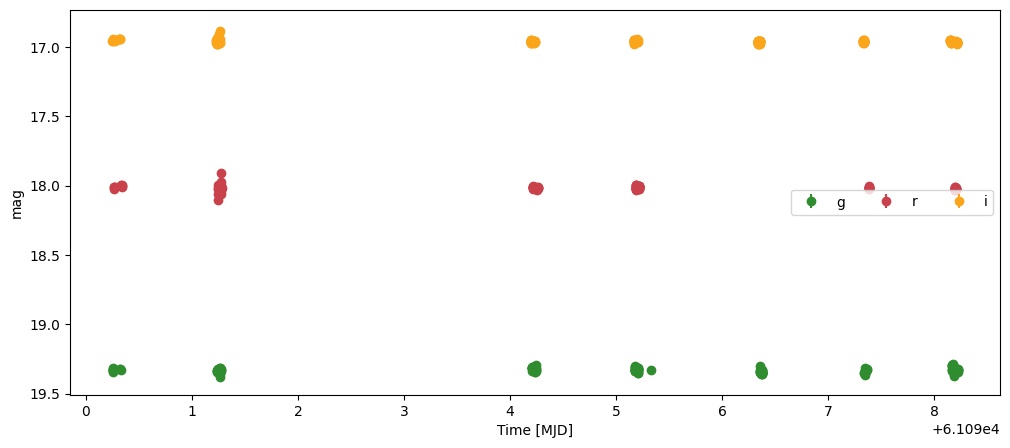

In [46]:
plot_alert_lc(lc, band='gri')

### Create a color-magnitude diagram

In [96]:
avg_mag_table = pd.DataFrame(columns=['diaObjectId', 'avg_mag_u', 'avg_mag_g', 'avg_mag_r', 
                                      'avg_mag_i', 'avg_mag_z', 'avg_mag_y'])

for i, dia_obj in tqdm(enumerate(data['diaObjectId'])):
    lc_alert = alert_lc(data, dia_obj, 
              alert_lc_type='prvDiaForcedSources',
                flux_ref='scienceFlux', 
                band='all')
    
    avg_mag_table.loc[i] = {
        "diaObjectId": dia_obj,
        "avg_mag_u": np.median(lc_alert['mag'][lc_alert['band']=='u']),
        "avg_mag_g": np.median(lc_alert['mag'][lc_alert['band']=='g']),
        "avg_mag_r": np.median(lc_alert['mag'][lc_alert['band']=='r']),
        "avg_mag_i": np.median(lc_alert['mag'][lc_alert['band']=='i']),
        "avg_mag_z": np.median(lc_alert['mag'][lc_alert['band']=='z']),
        "avg_mag_y": np.median(lc_alert['mag'][lc_alert['band']=='y'])
    }

3497it [01:07, 51.99it/s]


## 

### Add a new column with the Gaia DR3 parallaxes

In [97]:
# parallax in ARCSEC (convert from mas to arcsec)
avg_mag_table['parallax'] = [x['gaiadr3_Plx']/1000 for x in tqdm(data['xm'])]

# and now we can add one more column for distance
avg_mag_table['distance_pc'] = 1 / avg_mag_table['parallax']

100%|██████████| 3497/3497 [00:00<00:00, 534548.67it/s]


In [98]:
avg_mag_table.head(3)

,diaObjectId,avg_mag_u,avg_mag_g,avg_mag_r,avg_mag_i,avg_mag_z,avg_mag_y,parallax,distance_pc
0,170028526632697879,NaN,NaN,18.015288,16.962650,NaN,NaN,0.002986,334.907406
1,170028526451294284,NaN,18.607314,17.388676,16.800021,NaN,NaN,0.001166,857.927290
2,313871014343737493,NaN,NaN,NaN,18.781338,NaN,17.193239,0.005167,193.550876


Text(0, 0.5, 'g$_{abs}$ [mag]')

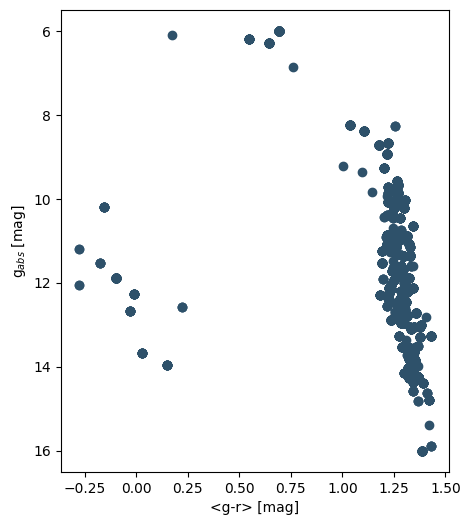

In [105]:
fig, ax = plt.subplots(figsize=(5,6))
ax.scatter(avg_mag_table['avg_mag_g']-avg_mag_table['avg_mag_r'],
           avg_mag_table['avg_mag_g'] - 5*np.log10(avg_mag_table['distance_pc']/10), 
           color="#2e516a")

ax.set_ylim(ax.get_ylim()[::-1])
ax.set_xlabel("<g-r> [mag]")
ax.set_ylabel("g$_{abs}$ [mag]")